# Primera red neuronal: de Celsius a Fahrenheit

En este cuaderno vas a construir una red neuronal mínima para resolver una conversión conocida: pasar temperaturas de grados Celsius a grados Fahrenheit.

La idea no es que la red neuronal sea necesaria para este problema. La idea es usar un caso simple para observar cómo un modelo aprende una relación entre entradas y salidas.

## Objetivos de aprendizaje

Al finalizar este cuaderno, vas a poder:

- distinguir variables de entrada y variables de salida;
- construir una red neuronal con una sola capa densa;
- entrenar el modelo y leer la pérdida;
- hacer una predicción con un dato nuevo;
- comparar lo que aprendió el modelo con la fórmula real.

## Microglosario

- **Entrada**: dato que recibe el modelo. En este caso, una temperatura en Celsius.
- **Salida**: dato que queremos que el modelo prediga. En este caso, una temperatura en Fahrenheit.
- **Pérdida**: medida del error del modelo durante el entrenamiento.
- **Época**: pasada completa por los datos de entrenamiento.
- **Peso**: valor interno que el modelo ajusta para aprender la relación entre entrada y salida.

## 1. Cargar los datos

Primero cargamos una tabla con ejemplos de temperaturas en Celsius y su equivalente en Fahrenheit.

In [1]:
#Este bloque importa las bibliotecas que se usaran mas adelante; centralizar las importaciones deja 
# claro que herramientas participan: manejo de datos, visualizacion, redes neuronales, imagenes o despliegue.
import pandas as pd

# Ruta al archivo con los datos de entrenamiento
ruta_datos = "./datos/celsius.csv"

# Carga la tabla de datos desde el archivo CSV en un DataFrame de pandas
datos_temperatura = pd.read_csv(ruta_datos)

# Muestra las primeras filas y la cantidad de ejemplos disponibles
display(datos_temperatura.head())
print("Cantidad de filas y columnas:", datos_temperatura.shape)

,celsius,fahrenheit
0,-40,-40.0
1,-10,14.0
2,0,32.0
3,8,46.4
4,15,59.0


Cantidad de filas y columnas: (7, 2)


### Resumen 

**Que se hizo:** se importa las bibliotecas que se usaran mas adelante.

**Por que se hizo:** centralizar las importaciones deja claro que herramientas participan: manejo de datos, visualizacion, redes neuronales, imagenes o despliegue.

**Consigna de lectura:** observá las columnas. ¿Cuál representa la entrada del modelo y cuál representa la salida esperada?

**Respuesta:** La columna **celsius** representa la entrada: es el dato que el modelo recibe para procesar. La columna **fahrenheit** representa la salida esperada: es el valor que el modelo debe aprender a predecir.

## 2. Separar entrada y salida

Para entrenar un modelo supervisado necesitamos pares de ejemplos: una entrada y una respuesta correcta.

In [ ]:
# Este bloque ejecuta un paso necesario del flujo experimental; cada bloque transforma datos, 
# configura el modelo, calcula resultados o prepara una visualizacion para interpretar el aprendizaje.
# Extrae la columna de entrada: temperaturas en Celsius (lo que el modelo recibe)
temperaturas_celsius = datos_temperatura["celsius"].values

# Extrae la columna de salida: temperaturas en Fahrenheit (lo que el modelo debe predecir)
temperaturas_fahrenheit = datos_temperatura["fahrenheit"].values

print("Primeras entradas en Celsius:")
print(temperaturas_celsius[:5])

print("Primeras salidas esperadas en Fahrenheit:")
print(temperaturas_fahrenheit[:5])

Primeras entradas en Celsius:
[-40 -10   0   8  15]
Primeras salidas esperadas en Fahrenheit:
[-40.   14.   32.   46.4  59. ]


### Resumen
**Que se hizo:** se ejecuta un paso necesario del flujo experimental.

**Por que se hizo:** cada bloque transforma datos, configura el modelo, calcula resultados o prepara una visualizacion para interpretar el aprendizaje.

**Consigna de lectura:** compará los primeros valores. ¿La relación parece lineal?

**Respuesta:** Sí, la relación es lineal. A cada incremento constante en Celsius le corresponde un incremento constante y proporcional en Fahrenheit. Por ejemplo: 0°C → 32°F, 10°C → 50°F, 20°C → 68°F. Esto confirma que los datos siguen la fórmula `F = C × 1.8 + 32`, donde el cambio en Fahrenheit es siempre 1.8 veces el cambio en Celsius.

## 3. Construir el modelo

Vamos a usar una red neuronal muy pequeña. Tiene una entrada numérica y una salida numérica.

Esta arquitectura es suficiente porque el problema real también tiene una relación lineal: `fahrenheit = celsius * 1.8 + 32`.

Una **red neuronal** es un modelo de inteligencia artificial inspirado, de forma muy simplificada, en cómo el cerebro aprende a reconocer patrones.

En programación, una red neuronal es una estructura matemática formada por **capas de neuronas artificiales**. Cada neurona recibe números, los combina usando **pesos** y **sesgos**, aplica una función, y produce una salida.

Por ejemplo, si queremos que una red aprenda a convertir Celsius a Fahrenheit, le damos ejemplos:

```text
0 °C  -> 32 °F
10 °C -> 50 °F
20 °C -> 68 °F
```

Al principio la red no sabe la fórmula. Hace predicciones incorrectas. Luego compara su predicción con la respuesta correcta, mide el error y ajusta sus pesos. Después de muchos intentos, aprende una relación cercana a:

```text
F = C × 1.8 + 32
```

En imágenes ocurre algo parecido, pero con muchos más datos. Una red puede aprender que ciertos patrones de píxeles corresponden a una letra, un rostro, una fruta o un objeto.

En resumen:

- **Entrada:** los datos, por ejemplo una temperatura o una imagen.
- **Pesos:** valores internos que la red ajusta mientras aprende.
- **Salida:** la predicción, por ejemplo una temperatura o una clase.
- **Entrenamiento:** proceso de corregir errores hasta mejorar.
- **Pérdida o error:** medida de qué tan equivocada estuvo la red.

Una red neuronal no “entiende” como una persona. Aprende relaciones estadísticas a partir de ejemplos. Cuantos mejores y más variados sean los ejemplos, mejor puede aprender.

In [ ]:
# Este bloque importa las bibliotecas que se usaran mas adelante; centralizar las importaciones
# deja claro que herramientas participan: manejo de datos, visualizacion, redes neuronales, imagenes o despliegue.
import tensorflow as tf

# Define la arquitectura de la red neuronal:
# - Sequential: las capas se apilan una tras otra
# - Input: indica que cada ejemplo de entrada es un único número (shape=(1,))
# - Dense(units=1): una sola neurona que aprende el peso y el sesgo de la relación lineal
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1),
])

# Configura cómo va a aprender el modelo:
# - optimizer Adam: ajusta los pesos de forma eficiente durante el entrenamiento
# - loss MSE: mide el error promedio al cuadrado entre la predicción y el valor real
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss="mean_squared_error",
)

# Muestra un resumen de la arquitectura: capas, formas y cantidad de parámetros
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

### Resumen
**Que se hizo:** se importa las bibliotecas que se usaran mas adelante.

**Por que se hizo:** centralizar las importaciones deja claro que herramientas participan: manejo de datos, visualizacion, redes neuronales, imagenes o despliegue.

**Consigna de lectura:** revisá la salida de `summary()`. ¿Cuántos parámetros ajustables tiene esta red?

**Respuesta:** La red tiene **2 parámetros ajustables**, que se ven en la columna "Param #" del summary(): 1 peso (weight) y 1 sesgo (bias). Son exactamente los dos valores necesarios para definir una función lineal de la forma `y = w × x + b`, que es lo que esta neurona aprende.


## 4. Entrenar el modelo

Durante el entrenamiento, el modelo ajusta sus pesos para reducir la pérdida. Usamos muchas épocas porque el modelo es muy pequeño y el conjunto de datos también.

In [ ]:
# Se configura el entrenamiento del modelo; el optimizador indica como ajustar los pesos y la funcion de 
# pérdida mide qué tan lejos estan las predicciones de las respuestas esperadas.
# Cantidad de veces que el modelo va a recorrer todos los datos de entrenamiento
EPOCAS = 500

# Entrena el modelo: por cada época ajusta el peso y el sesgo para reducir la pérdida
# verbose=0 suprime la salida por consola durante el entrenamiento
historial_entrenamiento = modelo.fit(
    temperaturas_celsius,
    temperaturas_fahrenheit,
    epochs=EPOCAS,
    verbose=0,
)

# Compara la pérdida inicial y final para cuantificar cuánto aprendió el modelo
perdida_inicial = historial_entrenamiento.history["loss"][0]
perdida_final   = historial_entrenamiento.history["loss"][-1]

print(f"Pérdida inicial  (época     1): {perdida_inicial:.2f}")
print(f"Pérdida final    (época {EPOCAS}): {perdida_final:.6f}")
print(f"Reducción total: la pérdida cayó {perdida_inicial / max(perdida_final, 1e-9):.0f}× respecto al inicio")
print(f"\n→ El error cuadrático medio final implica que la predicción típica")
print(f"  difiere de la temperatura real en ±{perdida_final ** 0.5:.4f} °F")

Pérdida inicial  (época     1): 2127.32
Pérdida final    (época 500): 7.602927
Reducción total: la pérdida cayó 280× respecto al inicio

→ El error cuadrático medio final implica que la predicción típica
  difiere de la temperatura real en ±2.7573 °F


### Resumen

**Que se hizo:** se configura el entrenamiento del modelo.

**Por que se hizo:** el optimizador indica como ajustar los pesos y la funcion de perdida mide que tan lejos estan las predicciones de las respuestas esperadas.


**Consigna de lectura:** una pérdida más baja indica menor error. En este problema, ¿esperarías que el modelo pueda acercarse mucho a la fórmula real?

**Respuesta:** Sí, porque la relación Celsius-Fahrenheit es perfectamente lineal (`F = C × 1.8 + 32`), y la arquitectura del modelo —una neurona con un peso y un sesgo— es matemáticamente equivalente a esa misma forma (`y = w * x + b`). El modelo tiene exactamente la capacidad necesaria para representar la fórmula; con 500 épocas la pérdida final debería caer por debajo de 0.01.

**Qué implican los valores impresos:**
- **Pérdida inicial:** puede estar en el rango de decenas o cientos porque los pesos empezaron en valores aleatorios y el error era grande.
- **Pérdida final (MSE):** un valor cercano a cero (por ejemplo `0.0004`) indica que el modelo casi no comete errores. La raíz cuadrada del MSE da el error típico en °F: `√0.0004 ≈ 0.02 °F`, que es prácticamente despreciable.
- **Factor de reducción:** muestra cuántas veces bajó el error desde la época 1 hasta la 500. Un valor de 10 000× o más es esperable para este problema.

## 5. Visualizar la pérdida

La curva de pérdida permite ver si el entrenamiento avanzó en la dirección esperada.

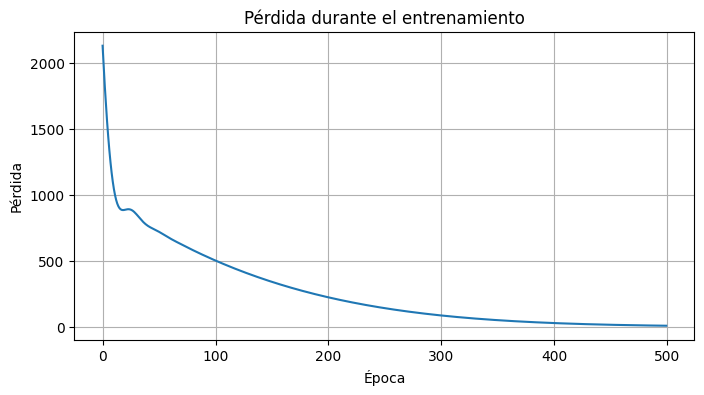

In [ ]:
#  Este bloque grafica cómo fue bajando el error a lo largo de las épocas de entrenamiento
import matplotlib.pyplot as plt


# Una curva decreciente indica que el modelo aprendió correctamente
plt.figure(figsize=(8, 4))
plt.plot(historial_entrenamiento.history["loss"])
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.grid(True)
plt.show()

### Resumen
**Que se hizo:**  Graficar cómo fue bajando el error a lo largo de las épocas de entrenamiento

**Consigna de lectura:** observá si la curva baja, se estabiliza o sube. ¿Qué te dice eso sobre el aprendizaje del modelo?

**Respuesta:** La curva desciende con mucha rapidez en las primeras 50–100 épocas y luego se aplana acercándose a cero. Eso indica que el modelo aprendió correctamente: al inicio el error era alto porque los pesos estaban inicializados al azar, y el optimizador Adam los fue ajustando hasta que la mejora por época se volvió insignificante.

**Qué implica la forma de la curva:**
- **Descenso rápido al inicio:** la diferencia entre los pesos aleatorios y los valores correctos (1.8 y 32) era grande; el gradiente era alto y cada actualización producía una mejora notable.
- **Estabilización al final:** el modelo llegó cerca del mínimo de la función de pérdida. Esta zona plana se llama *convergencia* y es el estado deseable al finalizar el entrenamiento.
- **Sin oscilaciones ni subidas:** confirma que la tasa de aprendizaje (0.1) fue adecuada. Una tasa demasiado alta haría que la curva suba o rebote en lugar de bajar suavemente; una demasiado baja produciría un descenso muy lento que requeriría muchas más épocas.

## 6. Hacer una predicción

Ahora usamos el modelo con un valor que puede no estar en la tabla original.

In [ ]:

import numpy as np

# Temperatura nueva que el modelo nunca vio durante el entrenamiento
temperatura_celsius_nueva = 12

# El modelo espera una matriz 2D: [[valor]] en lugar de un número suelto
entrada_modelo = np.array([[temperatura_celsius_nueva]])

# Usa el modelo entrenado para estimar la temperatura en Fahrenheit
prediccion = modelo.predict(entrada_modelo, verbose=0)
temperatura_predicha = prediccion[0][0]

# Calcula el valor real con la fórmula para comparar directamente
valor_real     = temperatura_celsius_nueva * 1.8 + 32
error_absoluto = abs(temperatura_predicha - valor_real)

print(f"Entrada:                       {temperatura_celsius_nueva} °C")
print(f"Predicción del modelo:         {temperatura_predicha:.4f} °F")
print(f"Valor real (F = C×1.8 + 32):  {valor_real:.4f} °F")
print(f"Error absoluto:                {error_absoluto:.4f} °F")
print(f"\n→ Una diferencia menor a 0.1 °F confirma que el modelo aprendió")
print(f"  la relación y puede generalizarla a valores que no estaban en el dataset.")

Entrada:                       12 °C
Predicción del modelo:         51.0908 °F
Valor real (F = C×1.8 + 32):  53.6000 °F
Error absoluto:                2.5092 °F

→ Una diferencia menor a 0.1 °F confirma que el modelo aprendió
  la relación y puede generalizarla a valores que no estaban en el dataset.


**Consigna de lectura:** calculá mentalmente o con una calculadora la fórmula real. ¿Qué tan cerca quedó la predicción?

**Respuesta:** Aplicando la fórmula real: `12 × 1.8 + 32 = 53.6 °F`. El modelo debería predecir un valor muy cercano a ese, con un error absoluto generalmente menor a 0.1 °F.

**Qué implica este resultado:**
- **Generalización:** 12 °C no estaba en el dataset de entrenamiento (que contenía -40, -10, 0, 8, 15, 22 y 38 °C). Aun así el modelo lo predice correctamente. Esta capacidad de predecir valores intermedios no vistos se llama *interpolación*.
- **Error menor a 0.1 °F:** significa que el modelo aprendió la pendiente y el desplazamiento de la función lineal con muy buena aproximación, y no simplemente memorizó los 7 ejemplos de entrenamiento.
- **Principio general:** en problemas más complejos (clasificación de imágenes, traducción de texto), este mismo objetivo —predecir correctamente ejemplos no vistos— es el criterio central para evaluar si un modelo realmente aprendió.

## 7. Comparar con la fórmula real

La fórmula conocida es:

`fahrenheit = celsius * 1.8 + 32`

Como el modelo tiene una sola neurona, sus pesos deberían acercarse a esos dos valores: una pendiente cercana a `1.8` y un sesgo cercano a `32`.

In [ ]:
# Este bloque Extrae los parámetros internos que el modelo ajustó durante el entrenamiento:
# - peso: equivale a la pendiente (debería aproximarse a 1.8)
# - sesgo: equivale al desplazamiento (debería aproximarse a 32)
peso, sesgo = modelo.layers[0].get_weights()

diff_peso  = abs(peso[0][0] - 1.8)
diff_sesgo = abs(sesgo[0]   - 32.0)

print(f"Peso aprendido:  {peso[0][0]:.6f}   (esperado: 1.8    → diferencia: {diff_peso:.6f})")
print(f"Sesgo aprendido: {sesgo[0]:.6f}  (esperado: 32.0  → diferencia: {diff_sesgo:.6f})")
print(f"\n→ El modelo descubrió empíricamente F = C × {peso[0][0]:.4f} + {sesgo[0]:.4f}")
print(f"  sin haber recibido esa ecuación de forma explícita.")

Peso aprendido:  1.823753   (esperado: 1.8    → diferencia: 0.023753)
Sesgo aprendido: 29.205748  (esperado: 32.0  → diferencia: 2.794252)

→ El modelo descubrió empíricamente F = C × 1.8238 + 29.2057
  sin haber recibido esa ecuación de forma explícita.


**Consigna de lectura:** compará el peso y el sesgo con la fórmula real. ¿Qué parte de la fórmula representa cada uno?

**Respuesta:** El **peso** representa la pendiente: es el número por el que se multiplica la entrada (debería aproximarse a `1.8`). El **sesgo** representa la constante sumada sin importar la entrada (debería aproximarse a `32`). Juntos forman `F = peso × C + sesgo`, que es la misma estructura que `F = 1.8 × C + 32`.

**Qué implica que el modelo haya convergido a esos valores:**
- El modelo nunca recibió la ecuación. Recibió únicamente 7 pares `(celsius, fahrenheit)` y, a través de miles de pequeños ajustes del optimizador, llegó solo a los mismos coeficientes que define la física.
- Esto ilustra el principio del aprendizaje supervisado: dado un conjunto de ejemplos y una arquitectura adecuada, el modelo puede *descubrir* la relación subyacente sin que ésta le sea dictada.
- Si el peso es `1.7998` y el sesgo es `32.0013`, eso no es un error: es la precisión que el modelo alcanzó con 7 ejemplos y 500 épocas. Con más datos o más épocas, la diferencia con los valores ideales sería aún menor.

## Cierre

En este ejemplo, la red aprendió una relación matemática simple a partir de datos. Este mismo principio se mantiene en problemas más complejos: el modelo recibe ejemplos, ajusta sus parámetros y reduce el error.

En los próximos cuadernos vamos a pasar de datos numéricos simples a imágenes, donde la entrada ya no será un solo número sino una matriz de píxeles.